# Chapter 3: RL Fundamentals: The Complete Picture

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arunpshankar/packt-final/blob/main/code/notebooks/part1_foundations/03_rl_fundamentals.ipynb)

> **Book:** *Reinforcement Learning for Large Language Models* — Arun Shankar & Michael Chertushkin (Packt, 2025)  
> **Chapter 3:** RL Fundamentals: The Complete Picture  
> **Notebook:** `part1_foundations/03_rl_fundamentals.ipynb`

---

## What this notebook covers

This is the companion notebook for Chapter 3 of the book. Run it on a free Colab T4 GPU. All code uses small, publicly available models (under 500 MB) that fit within the free tier memory limit.

**To open in Colab:** Click the badge above, or replace `github.com` with `githubtocolab.com` in the URL.


## Environment Setup

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    %pip install -q numpy matplotlib torch

print(f'Running in Colab: {IN_COLAB}')

Running in Colab: True


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import defaultdict

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('Imports OK.')

Imports OK.


---
## 1. GridWorld Environment

Our environment is a **5 x 5 grid**. The agent starts at the top-left corner `(0, 0)` and must reach the goal at `(4, 4)`. A wall at `(2, 2)` is impassable. Each step costs −0.01; reaching the goal gives +1.0.

| RL concept | GridWorld | LLM analogy |
|---|---|---|
| State $s$ | Agent position $(r, c)$ | Prompt + partial response so far |
| Action $a$ | Move: up / down / left / right | Pick next token from vocabulary |
| Reward $r$ | +1 at goal, −0.01 per step | Human preference score |
| Episode | One path from start to goal | One full response generation |
| Policy $\pi$ | Probability over 4 moves | Probability over ~50k tokens |

In [3]:
class GridWorld:
    """5x5 GridWorld with one wall cell and a goal cell."""

    ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # up, down, left, right
    ACTION_NAMES = ['up', 'down', 'left', 'right']
    N = 5
    WALL = (2, 2)
    GOAL = (4, 4)
    START = (0, 0)

    def __init__(self, max_steps: int = 50):
        self.max_steps = max_steps
        self.reset()

    def reset(self):
        self.pos = list(self.START)
        self.steps = 0
        return self._state_idx()

    def _state_idx(self) -> int:
        """Flatten (row, col) into a single integer state index."""
        return self.pos[0] * self.N + self.pos[1]

    def step(self, action: int):
        dr, dc = self.ACTIONS[action]
        nr, nc = self.pos[0] + dr, self.pos[1] + dc

        # Stay in bounds and avoid wall
        if 0 <= nr < self.N and 0 <= nc < self.N and (nr, nc) != self.WALL:
            self.pos = [nr, nc]

        self.steps += 1
        done = (tuple(self.pos) == self.GOAL) or (self.steps >= self.max_steps)
        reward = 1.0 if tuple(self.pos) == self.GOAL else -0.01
        return self._state_idx(), reward, done

    @property
    def n_states(self):
        return self.N * self.N

    @property
    def n_actions(self):
        return 4


env = GridWorld()
print(f'States : {env.n_states}')
print(f'Actions: {env.n_actions}')
print(f'Goal state index: {GridWorld.N * GridWorld.GOAL[0] + GridWorld.GOAL[1]}')

States : 25
Actions: 4
Goal state index: 24


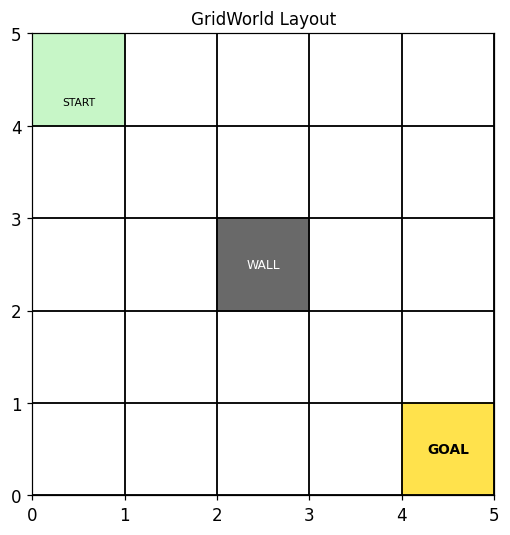

In [4]:
def render_grid(policy_probs=None, value_fn=None, title='GridWorld'):
    """Render the 5x5 grid with optional policy arrows and value estimates."""
    N = GridWorld.N
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlim(0, N); ax.set_ylim(0, N)
    ax.set_xticks(range(N + 1)); ax.set_yticks(range(N + 1))
    ax.grid(True, linewidth=1.2, color='black')
    ax.set_aspect('equal')

    arrow_dirs = [(-0.3, 0), (0.3, 0), (0, -0.3), (0, 0.3)]  # up,down,left,right in plot coords

    for r in range(N):
        for c in range(N):
            x, y = c + 0.5, (N - 1 - r) + 0.5
            state = r * N + c

            if (r, c) == GridWorld.WALL:
                ax.add_patch(patches.Rectangle((c, N - 1 - r), 1, 1, color='dimgray'))
                ax.text(x, y, 'WALL', ha='center', va='center', color='white', fontsize=8)
            elif (r, c) == GridWorld.GOAL:
                ax.add_patch(patches.Rectangle((c, N - 1 - r), 1, 1, color='gold', alpha=0.7))
                ax.text(x, y, 'GOAL', ha='center', va='center', fontsize=9, fontweight='bold')
            elif (r, c) == GridWorld.START:
                ax.add_patch(patches.Rectangle((c, N - 1 - r), 1, 1, color='lightgreen', alpha=0.5))
                ax.text(x, y - 0.25, 'START', ha='center', va='center', fontsize=7)
            else:
                if value_fn is not None:
                    v = value_fn[state]
                    ax.text(x, y + 0.25, f'{v:.2f}', ha='center', va='center',
                            fontsize=7, color='navy')

            if policy_probs is not None and (r, c) not in [GridWorld.WALL, GridWorld.GOAL]:
                probs = policy_probs[state]
                best_a = int(np.argmax(probs))
                dy, dx = arrow_dirs[best_a]
                ax.annotate('', xy=(x + dx, y + dy), xytext=(x, y),
                            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()


render_grid(title='GridWorld Layout')

---
## 2. Policy Representation

We represent the policy as a small neural network: a two-layer MLP that takes a one-hot state encoding as input and outputs action logits. This is analogous to how an LLM maps token embeddings to vocabulary logits.

Before training, the policy is essentially random — all actions are equally likely.

In [5]:
class PolicyNet(nn.Module):
    """Two-layer MLP policy for the GridWorld."""

    def __init__(self, n_states: int, n_actions: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, state_idx: int) -> torch.Tensor:
        one_hot = torch.zeros(env.n_states)
        one_hot[state_idx] = 1.0
        logits = self.net(one_hot)
        return F.log_softmax(logits, dim=-1)

    def sample_action(self, state_idx: int):
        log_probs = self(state_idx)
        dist = torch.distributions.Categorical(logits=log_probs)
        action = dist.sample()
        return action.item(), log_probs[action]


policy = PolicyNet(env.n_states, env.n_actions)
print('Policy network architecture:')
print(policy)
n_params = sum(p.numel() for p in policy.parameters())
print(f'\nTotal parameters: {n_params}')

Policy network architecture:
PolicyNet(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)

Total parameters: 1924


---
## 3. REINFORCE Algorithm

**REINFORCE** (Williams, 1992) is the simplest policy gradient algorithm:

1. **Collect** an episode by following the current policy
2. **Compute** discounted returns $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$
3. **Update** weights: $\theta \leftarrow \theta + \alpha \sum_t G_t \nabla_\theta \log \pi_\theta(a_t | s_t)$

Note the sign: we perform **gradient ascent** on expected return (or equivalently gradient descent on $-\log \pi \cdot G$).

As covered in Chapter 4 of the book, REINFORCE is the conceptual ancestor of PPO and GRPO — the difference is in how the return estimate is normalised and clipped.

In [6]:
def collect_episode(policy_net: PolicyNet, env: GridWorld):
    """Roll out one episode, return (log_probs, rewards)."""
    state = env.reset()
    log_probs, rewards = [], []

    for _ in range(env.max_steps):
        action, log_prob = policy_net.sample_action(state)
        state, reward, done = env.step(action)
        log_probs.append(log_prob)
        rewards.append(reward)
        if done:
            break

    return log_probs, rewards


def compute_returns(rewards: list, gamma: float = 0.99) -> torch.Tensor:
    """Compute discounted returns G_t for each timestep t."""
    G, returns = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32)
    # Normalise to reduce variance
    if returns.std() > 1e-8:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns


def reinforce_loss(log_probs: list, returns: torch.Tensor) -> torch.Tensor:
    """REINFORCE loss: -sum(log_pi * G_t)."""
    loss = 0.0
    for lp, G in zip(log_probs, returns):
        loss += -lp * G
    return loss


print('REINFORCE helper functions defined.')

REINFORCE helper functions defined.


---
## 4. Training for 500 Episodes

In [7]:
N_EPISODES = 500
GAMMA = 0.99
LR = 5e-3
LOG_EVERY = 50

policy = PolicyNet(env.n_states, env.n_actions)
optimizer = optim.Adam(policy.parameters(), lr=LR)
env = GridWorld(max_steps=50)

episode_rewards = []
episode_lengths = []

for ep in range(1, N_EPISODES + 1):
    log_probs, rewards = collect_episode(policy, env)
    returns = compute_returns(rewards, GAMMA)

    optimizer.zero_grad()
    loss = reinforce_loss(log_probs, returns)
    loss.backward()
    optimizer.step()

    episode_rewards.append(sum(rewards))
    episode_lengths.append(len(rewards))

    if ep % LOG_EVERY == 0:
        avg_r = np.mean(episode_rewards[-LOG_EVERY:])
        avg_l = np.mean(episode_lengths[-LOG_EVERY:])
        print(f'Episode {ep:4d}/{N_EPISODES}  '
              f'avg_reward={avg_r:+.3f}  avg_length={avg_l:.1f}')

print('\nTraining complete.')

Episode   50/500  avg_reward=+0.438  avg_length=33.0
Episode  100/500  avg_reward=+0.835  avg_length=15.5
Episode  150/500  avg_reward=+0.895  avg_length=11.5
Episode  200/500  avg_reward=+0.910  avg_length=10.0
Episode  250/500  avg_reward=+0.911  avg_length=9.9
Episode  300/500  avg_reward=+0.921  avg_length=8.9
Episode  350/500  avg_reward=+0.922  avg_length=8.8
Episode  400/500  avg_reward=+0.925  avg_length=8.5
Episode  450/500  avg_reward=+0.924  avg_length=8.6
Episode  500/500  avg_reward=+0.926  avg_length=8.4

Training complete.


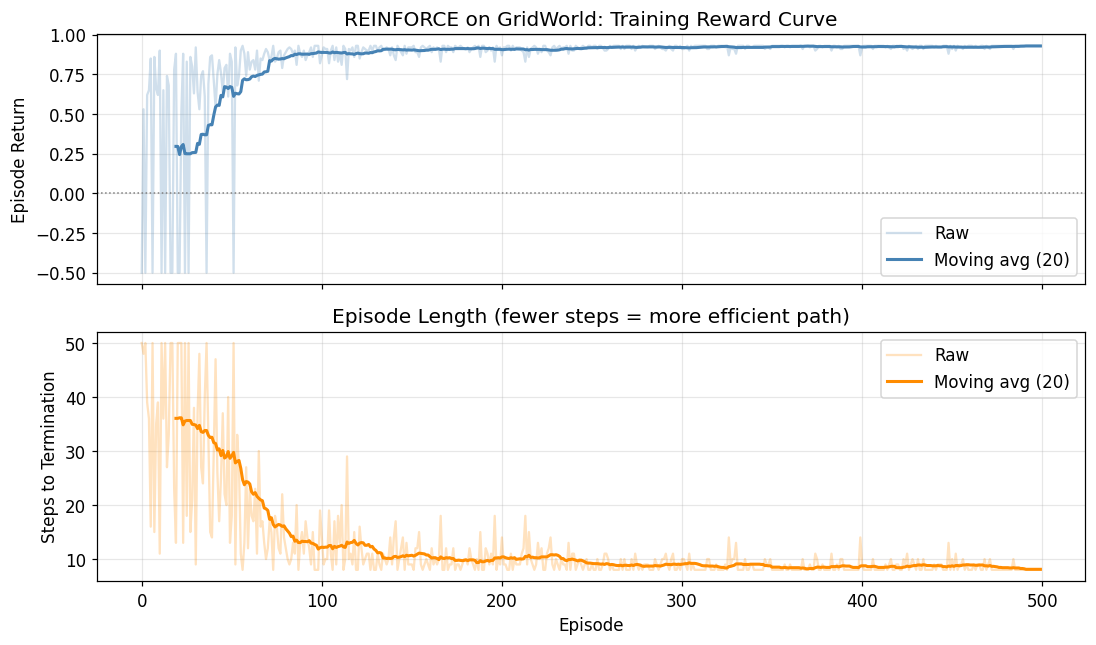

In [8]:
# Smooth and plot the reward curve
def moving_average(data, window=20):
    return np.convolve(data, np.ones(window) / window, mode='valid')


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

smoothed_rewards = moving_average(episode_rewards, window=20)
ax1.plot(episode_rewards, alpha=0.25, color='steelblue', label='Raw')
ax1.plot(
    range(19, N_EPISODES), smoothed_rewards,
    color='steelblue', linewidth=2, label='Moving avg (20)'
)
ax1.axhline(0, color='gray', linestyle=':', linewidth=1)
ax1.set_ylabel('Episode Return')
ax1.set_title('REINFORCE on GridWorld: Training Reward Curve')
ax1.legend()
ax1.grid(alpha=0.3)

smoothed_lengths = moving_average(episode_lengths, window=20)
ax2.plot(episode_lengths, alpha=0.25, color='darkorange', label='Raw')
ax2.plot(
    range(19, N_EPISODES), smoothed_lengths,
    color='darkorange', linewidth=2, label='Moving avg (20)'
)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Steps to Termination')
ax2.set_title('Episode Length (fewer steps = more efficient path)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

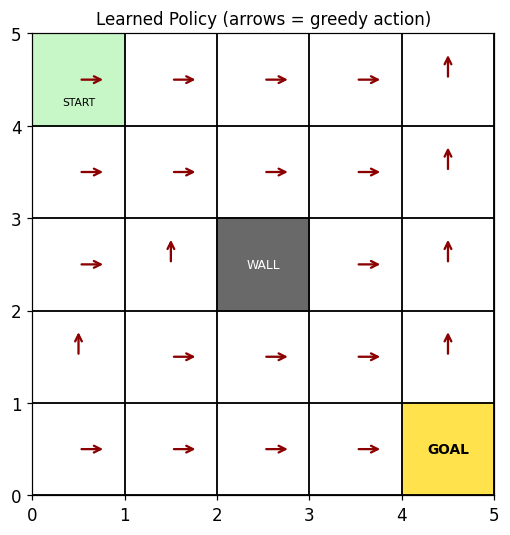

In [9]:
# Visualise the learned policy on the grid
policy_probs = {}
for s in range(env.n_states):
    with torch.no_grad():
        log_probs = policy(s)
        policy_probs[s] = torch.exp(log_probs).numpy()

render_grid(policy_probs=policy_probs, title='Learned Policy (arrows = greedy action)')

---
## 5. Value Function Estimation — Tabular TD(0)

The **value function** $V^\pi(s)$ estimates the expected return from state $s$ under policy $\pi$:

$$V^\pi(s) = \mathbb{E}_\pi\left[\sum_{t=0}^{\infty} \gamma^t r_t \,\Big|\, s_0 = s\right]$$

**TD(0)** (Temporal Difference) updates the value estimate after each step using the **Bellman equation**:

$$V(s) \leftarrow V(s) + \alpha \left[r + \gamma V(s') - V(s)\right]$$

The term $\delta = r + \gamma V(s') - V(s)$ is the **TD error** — the surprise signal. In actor-critic methods (Chapter 4), this becomes the **advantage** used to weight the policy gradient update.

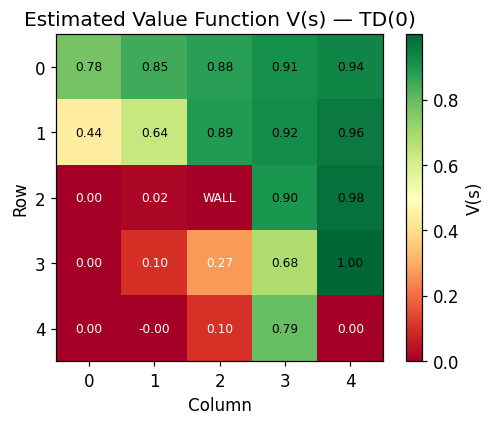

Highest value: state 19 = 1.000  (should be near goal)
Lowest  value: state 21 = -0.001


In [11]:
def estimate_value_function(
    policy_net: PolicyNet,
    env: GridWorld,
    n_episodes: int = 300,
    alpha: float = 0.1,
    gamma: float = 0.99,
) -> np.ndarray:
    """Tabular TD(0) value estimation under the given policy."""
    V = np.zeros(env.n_states)

    for _ in range(n_episodes):
        state = env.reset()
        done = False
        while not done:
            with torch.no_grad():
                action, _ = policy_net.sample_action(state)
            next_state, reward, done = env.step(action)
            td_error = reward + gamma * V[next_state] * (1 - done) - V[state]
            V[state] += alpha * td_error
            state = next_state

    return V


V = estimate_value_function(policy, env, n_episodes=300)

# Plot value function as a heatmap
N = GridWorld.N
V_grid = V.reshape(N, N)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(V_grid, cmap='RdYlGn', origin='upper')
plt.colorbar(im, ax=ax, label='V(s)')

for r in range(N):
    for c in range(N):
        label = f'{V_grid[r, c]:.2f}'
        if (r, c) == GridWorld.WALL:
            label = 'WALL'
        ax.text(c, r, label, ha='center', va='center', fontsize=8,
                color='black' if V_grid[r, c] > V_grid.min() + 0.3 * np.ptp(V_grid) else 'white')

ax.set_title('Estimated Value Function V(s) — TD(0)')
ax.set_xlabel('Column')
ax.set_ylabel('Row')
plt.tight_layout()
plt.show()

print(f'Highest value: state {V.argmax()} = {V.max():.3f}  (should be near goal)')
print(f'Lowest  value: state {V.argmin()} = {V.min():.3f}')

---
## 6. Mapping GridWorld Concepts to LLM RL

Everything we built above maps directly onto the LLM RL setting. Let us make the correspondence concrete.

In [12]:
# This cell is a printed conceptual mapping — no model needed

mapping = [
    ('Environment',  '5x5 grid',                  'text conversation / task'),
    ('State s',      '(row, col) position',        'prompt + tokens generated so far'),
    ('Action a',     'one of {up,down,left,right}','one token from vocabulary (~50k)'),
    ('Reward r',     '+1 at goal, -0.01 per step', 'human preference score (reward model)'),
    ('Episode',      'one path: start -> goal',    'one full response (all generated tokens)'),
    ('Policy pi',    '64-unit MLP',                'LLM transformer (billions of params)'),
    ('Value V(s)',   'tabular TD(0) estimate',     'critic head on top of LLM'),
    ('Return G_t',   'sum of discounted rewards',  'same — but gamma ≈ 1 for short responses'),
    ('REINFORCE',    'gradient ascent on J',       'same algorithm, vastly larger policy'),
]

col_w = [14, 28, 42]
header = f"{'Concept':<{col_w[0]}}  {'GridWorld':<{col_w[1]}}  {'LLM RL'}"
print(header)
print('-' * (sum(col_w) + 6))
for concept, grid_val, llm_val in mapping:
    print(f'{concept:<{col_w[0]}}  {grid_val:<{col_w[1]}}  {llm_val}')

Concept         GridWorld                     LLM RL
------------------------------------------------------------------------------------------
Environment     5x5 grid                      text conversation / task
State s         (row, col) position           prompt + tokens generated so far
Action a        one of {up,down,left,right}   one token from vocabulary (~50k)
Reward r        +1 at goal, -0.01 per step    human preference score (reward model)
Episode         one path: start -> goal       one full response (all generated tokens)
Policy pi       64-unit MLP                   LLM transformer (billions of params)
Value V(s)      tabular TD(0) estimate        critic head on top of LLM
Return G_t      sum of discounted rewards     same — but gamma ≈ 1 for short responses
REINFORCE       gradient ascent on J          same algorithm, vastly larger policy


---
## 7. KL Penalty — Effect on Policy Entropy

In LLM RL we add a **KL penalty** to prevent the policy from drifting too far from the reference (pre-trained) policy. This is the same idea in GridWorld: we add a penalty that discourages the agent from changing its action distribution too aggressively.

The modified objective is:

$$J_{\text{KL}}(\theta) = J(\theta) - \beta \cdot D_{\text{KL}}(\pi_\theta \| \pi_{\text{ref}})$$

A larger $\beta$ keeps the policy closer to the reference — but may prevent it from improving. A smaller $\beta$ allows more exploration but risks **reward hacking** (the topic of Chapter 7).

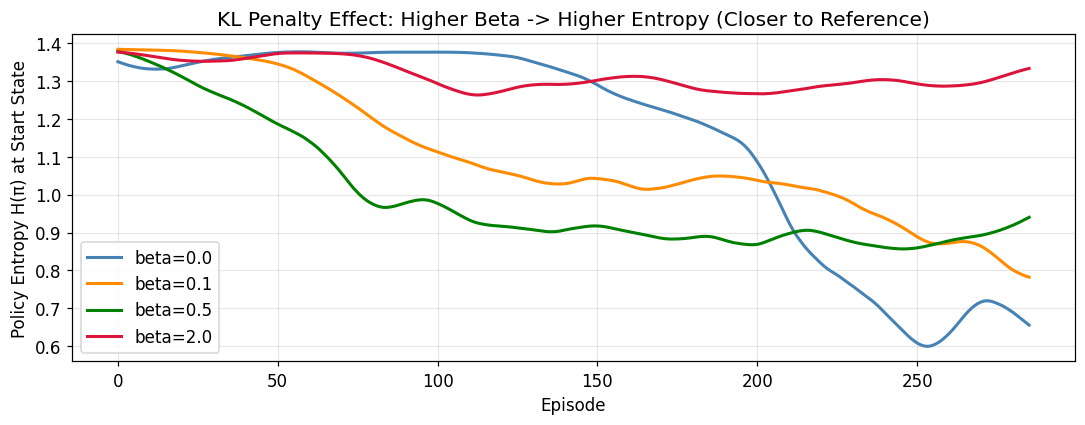

Uniform policy entropy (reference): log(4) = 1.386 nats


In [13]:
def reinforce_with_kl(
    env: GridWorld,
    beta: float,
    n_episodes: int = 300,
    lr: float = 5e-3,
    gamma: float = 0.99,
):
    """REINFORCE with a KL penalty against a fixed reference policy."""
    # Reference policy: uniform random (untrained)
    ref_policy = PolicyNet(env.n_states, env.n_actions)
    for p in ref_policy.parameters():
        p.requires_grad_(False)

    trained_policy = PolicyNet(env.n_states, env.n_actions)
    optimizer = optim.Adam(trained_policy.parameters(), lr=lr)

    entropies = []

    for ep in range(n_episodes):
        log_probs_pi, rewards = collect_episode(trained_policy, env)
        returns = compute_returns(rewards, gamma)

        # KL penalty: average KL across all visited states in episode
        state = env.reset()
        kl_total = torch.tensor(0.0)
        for _ in range(min(len(rewards), env.max_steps)):
            lp_new = trained_policy(state)
            lp_ref = ref_policy(state)
            # KL(new || ref) = sum(exp(lp_new) * (lp_new - lp_ref))
            kl_total = kl_total + (lp_new.exp() * (lp_new - lp_ref)).sum()
            action, _ = trained_policy.sample_action(state)
            state, _, done = env.step(action)
            if done:
                break
        kl_avg = kl_total / max(len(rewards), 1)

        pg_loss = reinforce_loss(log_probs_pi, returns)
        total_loss = pg_loss + beta * kl_avg

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # Measure policy entropy at starting state
        with torch.no_grad():
            lp = trained_policy(0)          # state 0 = start
            p = lp.exp()
            H = -(p * lp).sum().item()
        entropies.append(H)

    return entropies


betas = [0.0, 0.1, 0.5, 2.0]
colors = ['steelblue', 'darkorange', 'green', 'crimson']
results = {}

for beta in betas:
    results[beta] = reinforce_with_kl(env, beta=beta, n_episodes=300)

fig, ax = plt.subplots(figsize=(10, 4))
for beta, color in zip(betas, colors):
    smoothed = moving_average(results[beta], window=15)
    ax.plot(smoothed, color=color, linewidth=2, label=f'beta={beta}')

ax.set_xlabel('Episode')
ax.set_ylabel('Policy Entropy H(π) at Start State')
ax.set_title('KL Penalty Effect: Higher Beta -> Higher Entropy (Closer to Reference)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Uniform policy entropy (reference): log(4) =', round(np.log(4), 3), 'nats')

---
## Summary

| Concept | Implementation | Key Takeaway |
|---|---|---|
| GridWorld | 5x5 grid, 25 states, 4 actions | Cleanest RL sandbox |
| Policy net | 2-layer MLP, log_softmax output | Same architecture pattern as LLM head |
| REINFORCE | $-\log\pi \cdot G_t$ loss | Ancestor of PPO / GRPO |
| TD(0) value | Bellman bootstrap update | Basis for advantage in actor-critic |
| KL penalty | Added to REINFORCE loss | Core of PPO-KL, RLHF penalty term |

In **Chapter 4** we move from GridWorld to language models, setting up the compute environment and running our first RL training loop on a real LLM.